# MSML612 Final Project Demo

## Libraries and Paths

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

pred_dir = '/scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/demo_predictions'
print(" Libraries loaded")
print(f" Predictions directory: {pred_dir}")

 Libraries loaded
 Predictions directory: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/demo_predictions


 ## Loading Predictions and Metrics

In [8]:
models = ['supervised_single', 'supervised_dual', 'self_single', 'self_dual']
model_names = {
    'supervised_single': 'Supervised Single (Baseline)',
    'supervised_dual': 'Supervised Dual (Ours)',
    'self_single': 'Self-Supervised Single',
    'self_dual': 'Self-Supervised Dual'
}
horizons = [96, 192, 336, 720]

predictions = {}
metrics = {}

for model in models:
    predictions[model] = {}
    metrics[model] = {}
    for h in horizons:
        pred_file = os.path.join(pred_dir, model, f't{h}_pred.npy')
        metric_file = os.path.join(pred_dir, model, f't{h}_metrics.csv')
        
        if os.path.exists(pred_file):
            predictions[model][h] = np.load(pred_file)
        else:
            predictions[model][h] = None
            
        if os.path.exists(metric_file):
            metrics[model][h] = np.loadtxt(metric_file, delimiter=',', skiprows=1)
        else:
            metrics[model][h] = None

ground_truth = {}
for h in horizons:
    gt_file = os.path.join(pred_dir, f'ground_truth_t{h}.npy')
    if os.path.exists(gt_file):
        ground_truth[h] = np.load(gt_file)
    else:
        ground_truth[h] = None

print(" All predictions loaded:")
for model in models:
    count = sum(1 for h in horizons if predictions[model][h] is not None)
    print(f"   {model_names[model]}: {count} horizons")

 All predictions loaded:
   Supervised Single (Baseline): 4 horizons
   Supervised Dual (Ours): 4 horizons
   Self-Supervised Single: 4 horizons
   Self-Supervised Dual: 1 horizons


## What the Model Sees and predicts

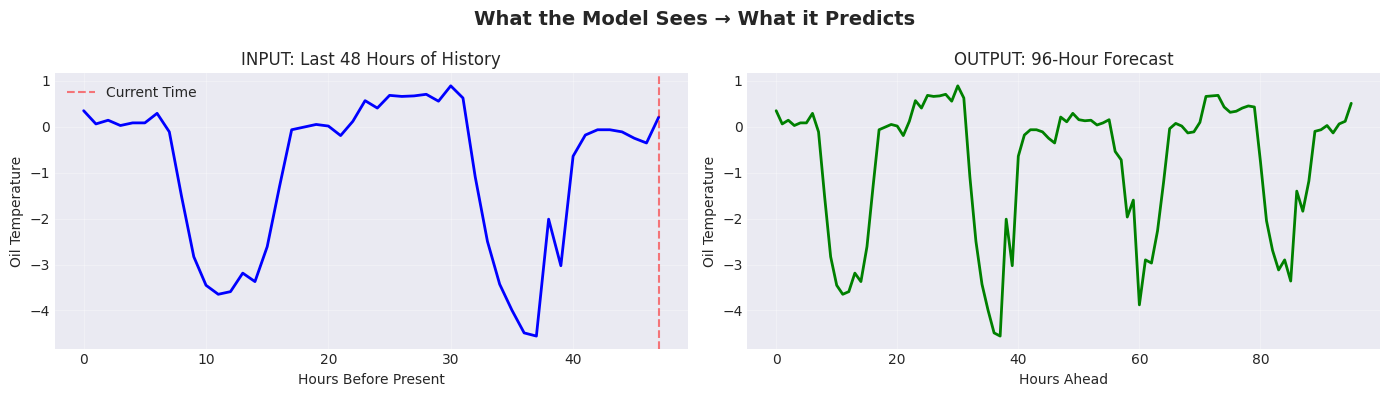

 The model takes 336 hours of history (not just 48 shown) and predicts 96 hours ahead


In [9]:
gt_sample = ground_truth[96]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

input_hist = gt_sample[0, :48, 0]
ax1.plot(range(48), input_hist, 'b-', linewidth=2)
ax1.axvline(x=47, color='r', linestyle='--', alpha=0.5, label='Current Time')
ax1.set_xlabel('Hours Before Present', fontsize=10)
ax1.set_ylabel('Oil Temperature', fontsize=10)
ax1.set_title('INPUT: Last 48 Hours of History', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

output_forecast = gt_sample[0, :96, 0]
ax2.plot(range(96), output_forecast, 'g-', linewidth=2)
ax2.set_xlabel('Hours Ahead', fontsize=10)
ax2.set_ylabel('Oil Temperature', fontsize=10)
ax2.set_title('OUTPUT: 96-Hour Forecast', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.suptitle('What the Model Sees → What it Predicts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" The model takes 336 hours of history (not just 48 shown) and predicts 96 hours ahead")

## Model Comparison Across Horizons

In [10]:
model_styles = {
    'supervised_single': {'color': 'blue', 'linestyle': '--', 'label': 'Supervised Single (Baseline)'},
    'supervised_dual': {'color': 'red', 'linestyle': '--', 'label': 'Supervised Dual (Ours)'},
    'self_single': {'color': 'green', 'linestyle': '--', 'label': 'Self-Supervised Single'},
    'self_dual': {'color': 'orange', 'linestyle': '--', 'label': 'Self-Supervised Dual'},
}

def plot_forecast_comparison(horizon):
    gt = ground_truth[horizon]
    if gt is None:
        print(f" No ground truth for T={horizon}")
        return
    
    fig, ax = plt.subplots(figsize=(14, 6))
    hours = range(horizon)
    ax.plot(hours, gt[0, :, 0], 'k-', linewidth=2.5, label='Ground Truth')
    
    for model in models:
        pred = predictions[model].get(horizon)
        if pred is not None:
            style = model_styles[model]
            ax.plot(hours, pred[0, :, 0], 
                   color=style['color'], 
                   linestyle=style['linestyle'], 
                   linewidth=1.5, 
                   label=style['label'],
                   alpha=0.8)
    
    ax.set_xlabel('Hours Ahead', fontsize=12)
    ax.set_ylabel('Oil Temperature', fontsize=12)
    ax.set_title(f'Forecast Comparison - {horizon} Hours Ahead', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

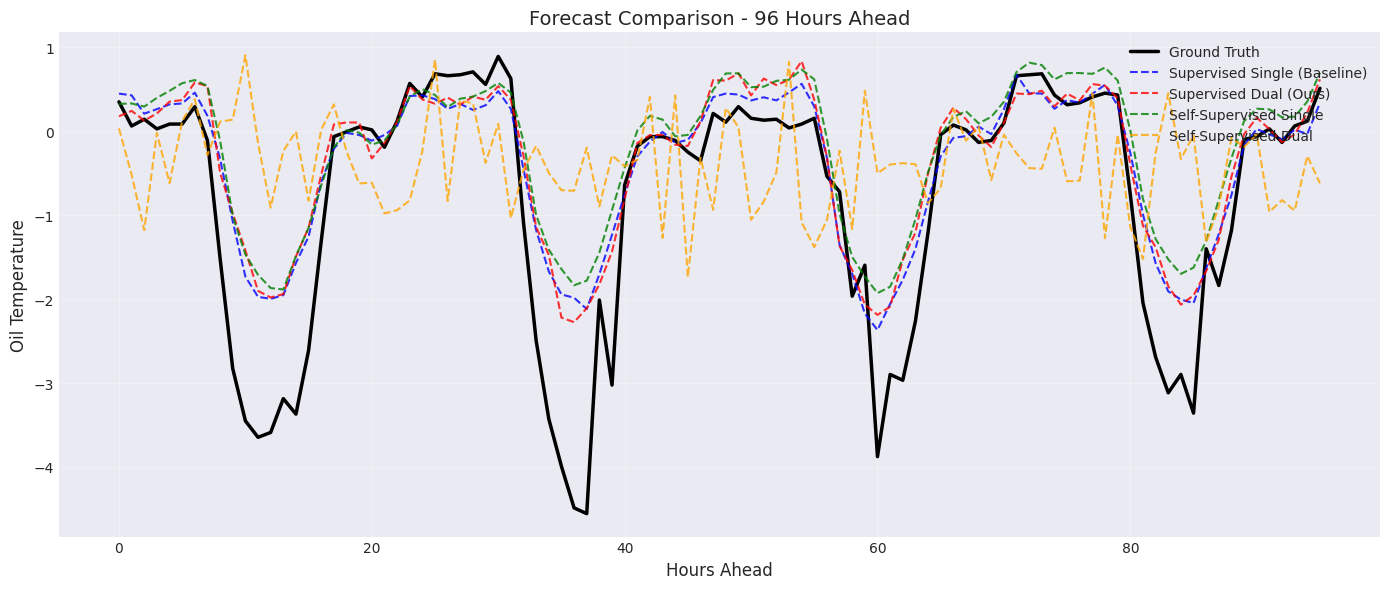

In [11]:
plot_forecast_comparison(96)

In [12]:
print("\n MODEL PERFORMANCE - T=96 (4 days)\n")
print(f"{'Model':<35} {'MSE':<12} {'MAE':<12}")
for model in models:
    if metrics[model].get(96) is not None:
        mse = metrics[model][96][0]
        mae = metrics[model][96][1]
        print(f"{model_names[model]:<35} {mse:.6f}   {mae:.6f}")


 MODEL PERFORMANCE - T=96 (4 days)

Model                               MSE          MAE         
Supervised Single (Baseline)        0.324952   0.364597
Supervised Dual (Ours)              0.333947   0.369478
Self-Supervised Single              0.394611   0.417975
Self-Supervised Dual                0.834908   0.619337


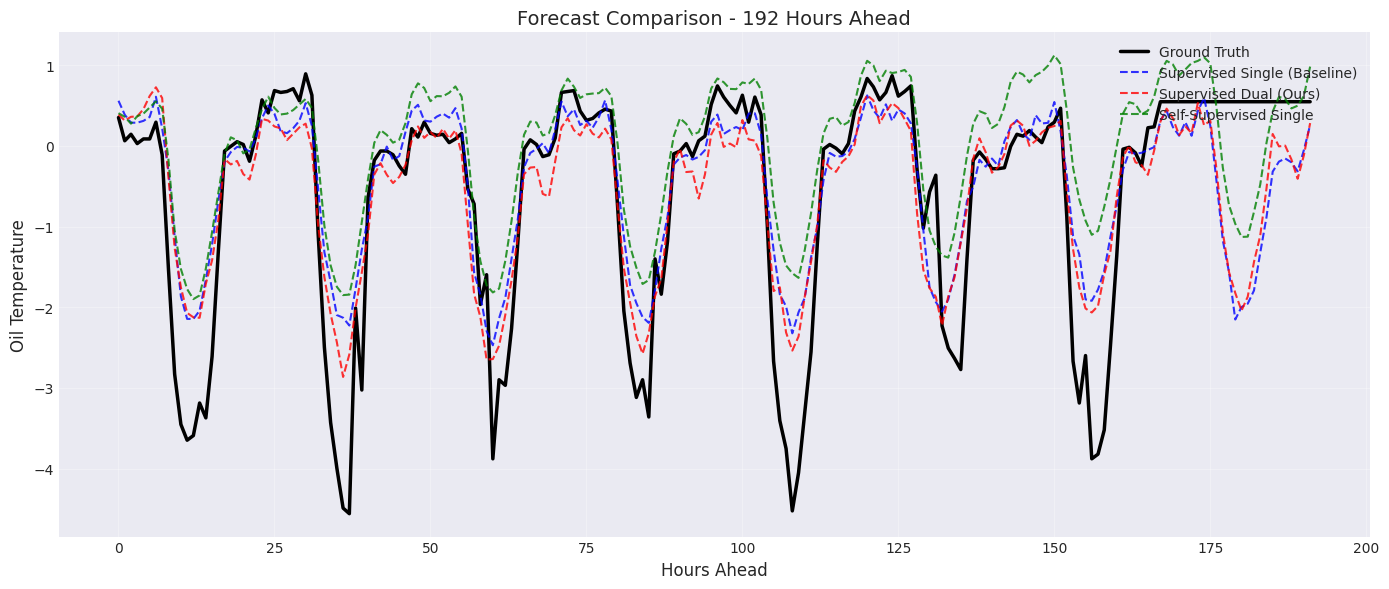

In [13]:
plot_forecast_comparison(192)

In [14]:
print("\n MODEL PERFORMANCE - T=192 (8 days)\n")
print(f"{'Model':<35} {'MSE':<12} {'MAE':<12}")
for model in models:
    if metrics[model].get(192) is not None:
        mse = metrics[model][192][0]
        mae = metrics[model][192][1]
        print(f"{model_names[model]:<35} {mse:.6f}   {mae:.6f}")


 MODEL PERFORMANCE - T=192 (8 days)

Model                               MSE          MAE         
Supervised Single (Baseline)        0.404608   0.409927
Supervised Dual (Ours)              0.356850   0.398806
Self-Supervised Single              0.487664   0.479350


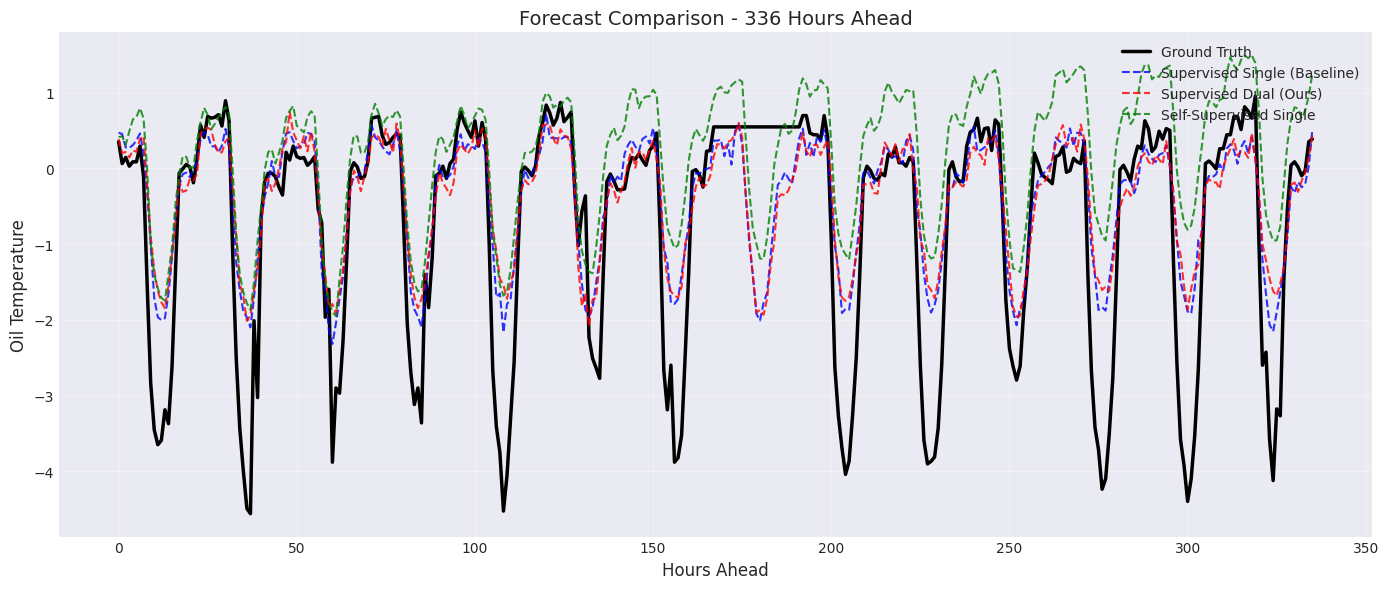

In [15]:
plot_forecast_comparison(336)

In [16]:
print("\n MODEL PERFORMANCE - T=336 (14 days)\n")
print(f"{'Model':<35} {'MSE':<12} {'MAE':<12}")
for model in models:
    if metrics[model].get(336) is not None:
        mse = metrics[model][336][0]
        mae = metrics[model][336][1]
        print(f"{model_names[model]:<35} {mse:.6f}   {mae:.6f}")


 MODEL PERFORMANCE - T=336 (14 days)

Model                               MSE          MAE         
Supervised Single (Baseline)        0.429513   0.413931
Supervised Dual (Ours)              0.468906   0.424065
Self-Supervised Single              0.607836   0.556987


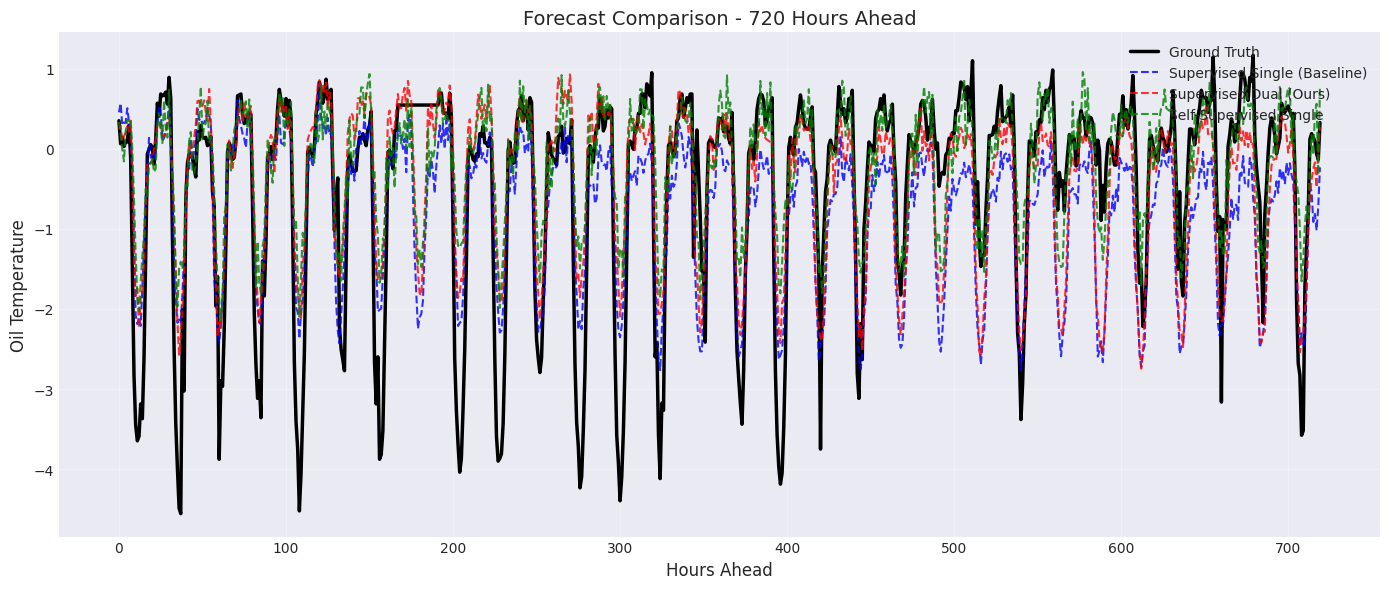

In [17]:
plot_forecast_comparison(720)

In [18]:
print("\n MODEL PERFORMANCE - T=720 (30 days)\n")
print(f"{'Model':<35} {'MSE':<12} {'MAE':<12}")
for model in models:
    if metrics[model].get(720) is not None:
        mse = metrics[model][720][0]
        mae = metrics[model][720][1]
        print(f"{model_names[model]:<35} {mse:.6f}   {mae:.6f}")


 MODEL PERFORMANCE - T=720 (30 days)

Model                               MSE          MAE         
Supervised Single (Baseline)        0.414935   0.470046
Supervised Dual (Ours)              0.364374   0.421506
Self-Supervised Single              0.457312   0.475520


## Best Model for each T

 BEST MODEL BY HORIZON
Horizon      Best Model                          MSE         
T= 96 ( 4 days)   Supervised Single (Baseline)        0.324952
T=192 ( 8 days)   Supervised Dual (Ours)              0.356850
T=336 (14 days)   Supervised Single (Baseline)        0.429513
T=720 (30 days)   Supervised Dual (Ours)              0.364374


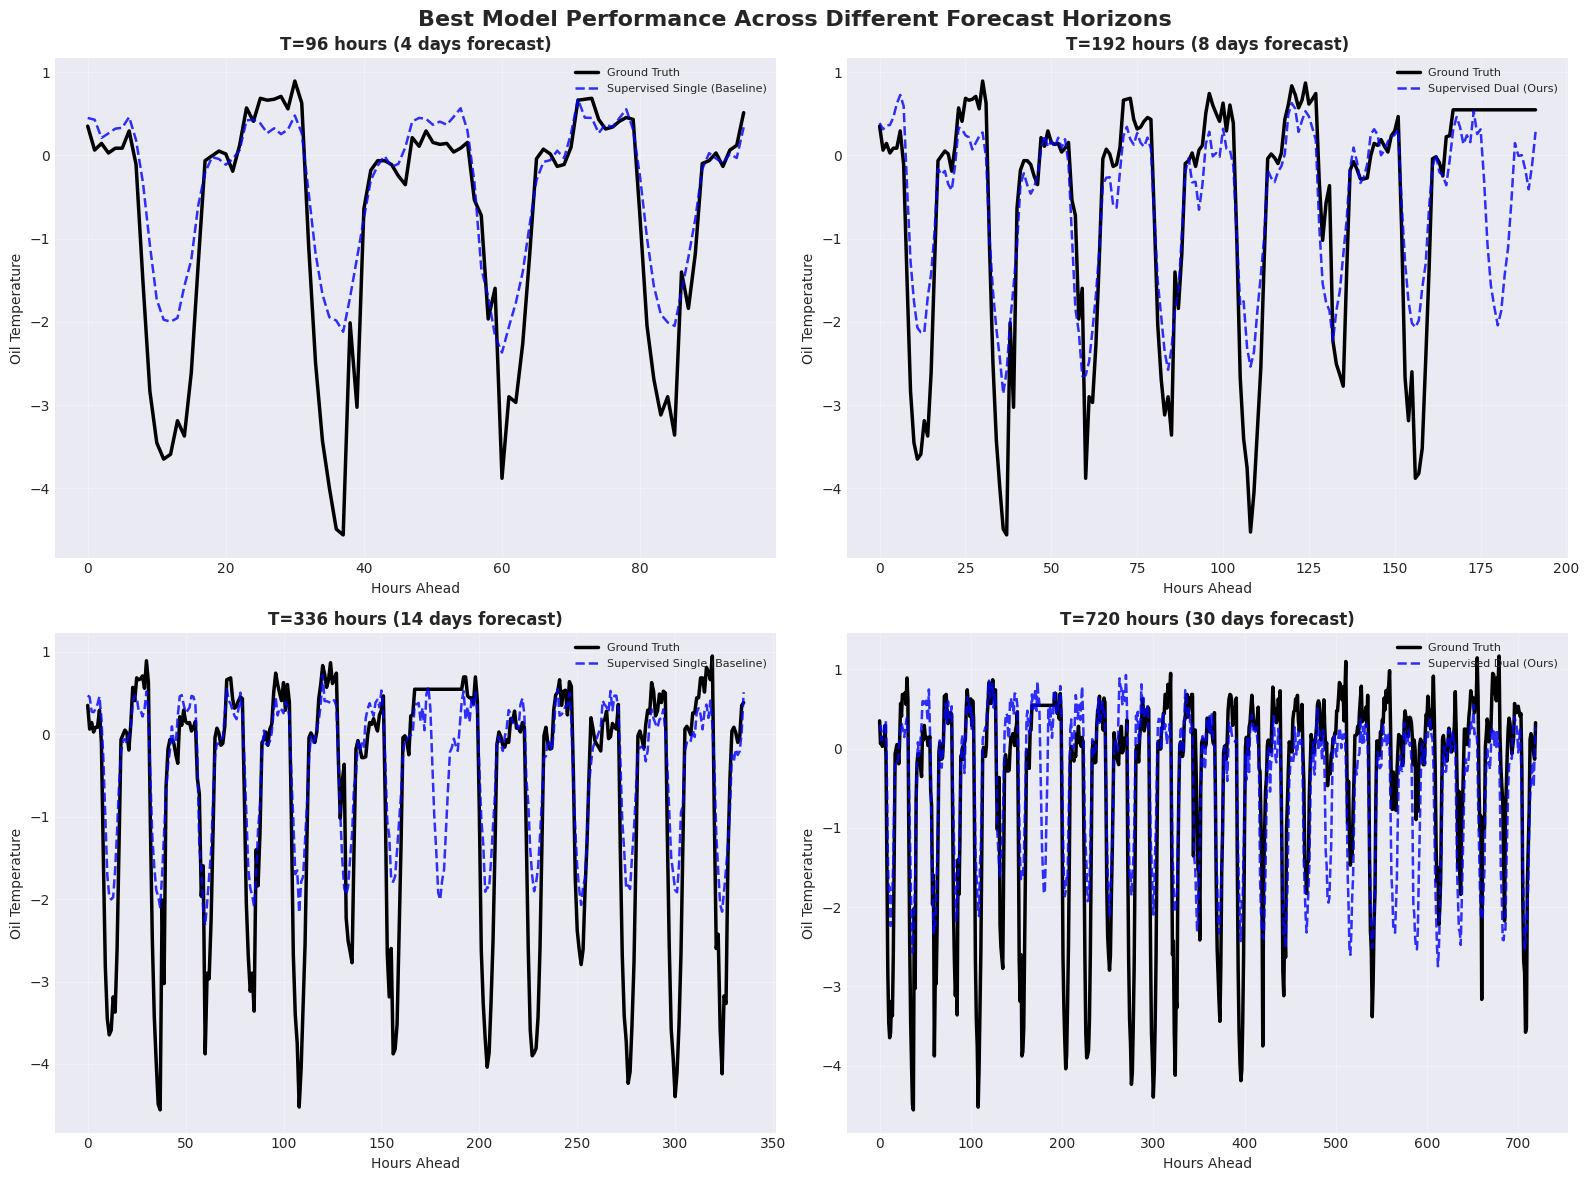

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
best_models = {
    96: {'name': 'Supervised Single (Baseline)', 'model_key': 'supervised_single'},
    192: {'name': 'Supervised Dual (Ours)', 'model_key': 'supervised_dual'},
    336: {'name': 'Supervised Single (Baseline)', 'model_key': 'supervised_single'},
    720: {'name': 'Supervised Dual (Ours)', 'model_key': 'supervised_dual'}
}

print(" BEST MODEL BY HORIZON")
print(f"{'Horizon':<12} {'Best Model':<35} {'MSE':<12}")

for idx, h in enumerate(horizons):
    best = best_models[h]
    mse_val = metrics[best['model_key']][h][0]
    print(f"T={h:3d} ({h//24:2d} days)   {best['name']:<35} {mse_val:.6f}")
    
    ax = axes[idx]
    gt = ground_truth[h]
    pred = predictions[best['model_key']][h]
    hours = range(h)
    
    ax.plot(hours, gt[0, :, 0], 'k-', linewidth=2.5, label='Ground Truth')
    ax.plot(hours, pred[0, :, 0], 'b--', linewidth=1.8, label=best['name'], alpha=0.8)
    
    ax.set_xlabel('Hours Ahead', fontsize=10)
    ax.set_ylabel('Oil Temperature', fontsize=10)
    ax.set_title(f'T={h} hours ({h//24} days forecast)', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Best Model Performance Across Different Forecast Horizons', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()